In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt

from robotblockset.tools import get_rbs_path

np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [3]:
from robotblockset.mujoco.robots_pymujoco import mujoco_scene
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/panda_box_scene.xml"
scene = mujoco_scene(MODEL_PATH, show_camera=None, verbose=1)

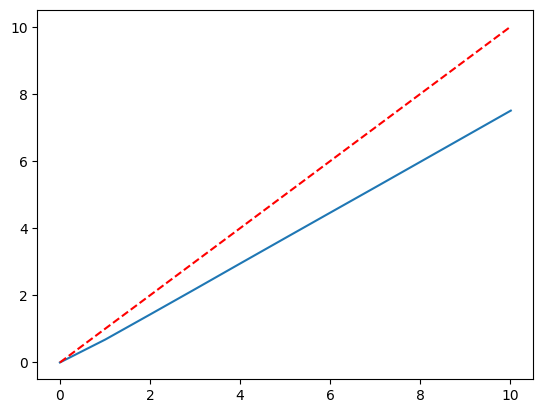

In [4]:
i = 0
t0=time.time()
tr0 = scene.data.time
tt = time.time()-t0
ttr = scene.data.time-tr0
while i<10:
    time.sleep(1)
    tt = np.vstack((tt, time.time()-t0))
    ttr = np.vstack((ttr, scene.data.time-tr0))
    i+=1
plt.plot(tt, ttr, tt, tt, 'r--')


In [5]:
from robotblockset.mujoco.robots_pymujoco import panda
r = panda(scene=scene)

[RBS_INFO] [1773556068.822527647] [panda_PyMuJoCo]: Robot connected to MuJoCo


In [6]:
# Callback for Update
it = 0
def CaptureRobot(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt, xtw, vtw, rxtw, rvtw, rrxtw, rrvtw, rTbt, tc
    if it == 0:
        tt = np.array(r.t)
        twall = time.time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
        xtw = r.x
        vtw = r.v
        rxtw = r.x_ref
        rvtw = r.v_ref
        rrxtw = r._command.rx
        rrvtw = r._command.rv
        rTbt = r.GetBasePose(out="x")
        tc = r._last_control_time
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time.time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
        xtw = np.vstack((xtw, r.x))
        vtw = np.vstack((vtw, r.v))
        rxtw = np.vstack((rxtw, r.x_ref))
        rvtw = np.vstack((rvtw, r.v_ref))
        rrxtw = np.vstack((rrxtw, r._command.rx))
        rrvtw = np.vstack((rrvtw, r._command.rv))
        rTbt = np.vstack((rTbt, r.GetBasePose(out="x")))
        tc = np.vstack((tc, r._last_control_time))

    it += 1

In [7]:
r.SetCaptureCallback(CaptureRobot)
# r.Restart()
r.ResetTime()
it = 0
r.StartCapture()
r.JMove(r.q_home,1)
r.Wait(1)
r.CMoveFor([0, 0, -0.1],1)
r.Wait(1)
r.CMoveFor([0, 0, 0.2],1)
r.Wait(1)
r.StopCapture()


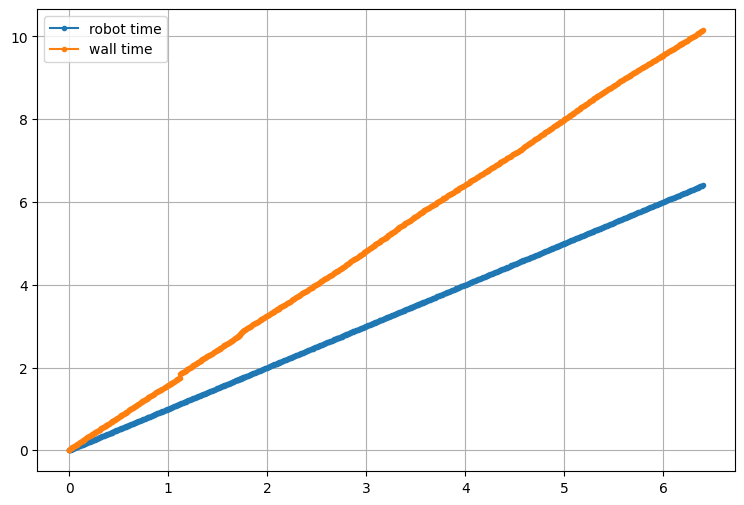

In [8]:
fig, ax = plt.subplots(1, 1, num=1, figsize=(9, 6))
ax.plot(tt, trob - trob[0], ".-", label='robot time')
ax.plot(tt, twall - twall[0], ".-", label='wall time')
ax.legend()
ax.grid()

Text(0.5, 1.0, 'mode')

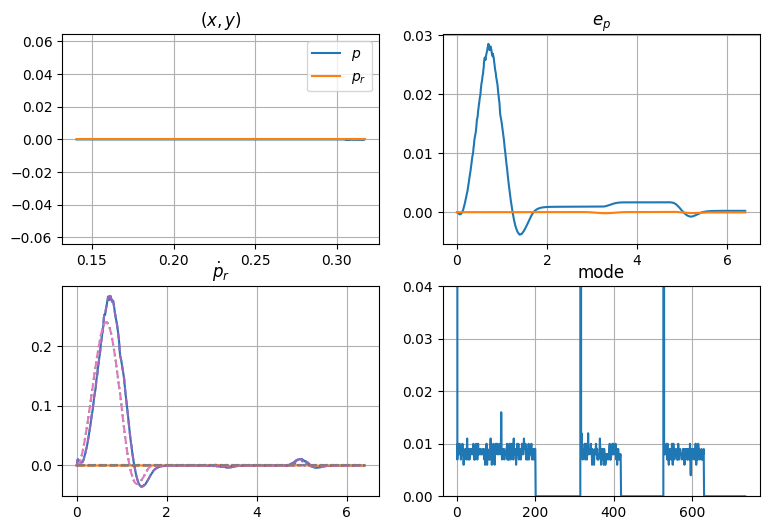

In [9]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(9, 6))
ax[0, 0].plot(xtw[:,0],xtw[:,1], label="$p$")
ax[0, 0].plot(rxtw[:,0],rxtw[:,1], label="$p_r$")
ax[0, 0].grid()
ax[0, 0].axis("equal")
ax[0, 0].set_title("$(x,y)$")
ax[0, 0].legend()
# ax[1, 0].plot(tt, np.linalg.norm(vt[:,:2], axis=-1), label="$\\|\\dot p\\|$")
# ax[1, 0].plot(tt, np.linalg.norm(rvt[:,:2], axis=-1), label="$\\|\\dot p_r\\|$")
# ax[1, 0].plot(tt, np.linalg.norm(vtw[:,:2], axis=-1), '--', label="$\\|\\dot p_w\\|$")
# ax[1, 0].plot(tt, np.linalg.norm(rvtw[:,:2], axis=-1), '--', label="$\\|\\dot p_{rw}\\|$")
ax[1, 0].plot(tt, vt[:,:2], label="$\\dot p$")
ax[1, 0].plot(tt, rvt[:,:2], ":", label="$\\dot p_r$")
ax[1, 0].plot(tt, vtw[:,:2], '--', label="$\\dot p_w$")
ax[1, 0].plot(tt, rvtw[:,:2], '--', label="$\\dot p_{rw}$")
ax[1, 0].grid()
ax[1, 0].set_title("$\\dot p_r$")
# ax[1, 0].legend()

ax[0, 1].plot(tt, rxt[:,:2]-xt[:,:2], label="$e_p$")
# ax[0, 1].plot(tt, xt[:,:2], label="$p$")
# ax[0, 1].plot(tt, rxt[:,:2], ':', label="$p_r$")
# ax[0, 1].plot(tt, xtw[:,:2], '--', label="$p_w$")
# ax[0, 1].plot(tt, rxtw[:,:2], '-', label="$p_{rw}$")
ax[0, 1].grid()
ax[0, 1].set_title("$e_p$")
# ax[0, 1].legend()

# ax[1, 1].plot(tt, xerr(rTbt,np.outer(np.ones((rTbt.shape[0])), rTbt[0])), label="Robot base offset")
ax[1, 1].plot(np.diff(tc, axis=0))
ax[1, 1].set_ylim((0, 0.04))
ax[1, 1].grid()
# ax[1, 1].legend()
ax[1, 1].set_title("mode")

In [10]:
# r.scene.mj_pause()
r.scene.mj_run()

In [11]:
r.JMove(r.q_home, 2)
r.SetMocapPose("Target", r.x)

In [12]:
r.CMoveFor([0, 0, -0.1], t=2, wait=3)

0

""

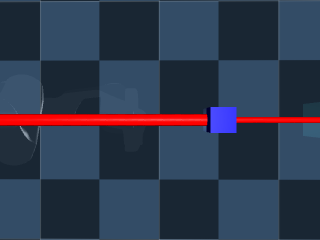

In [13]:
frame = r.scene.mj_capture_camera(camera="Robot")
media.show_image(frame)

In [14]:
duration = 1  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
r.JMove(r.q_home,1)
r.CMoveFor([0, 0, -0.1], t=2, asynchronous=True)
r.ResetTime()
print(f"Frame {len(frames)} at time {r.scene.data.time:.2f} seconds")
while r.t < 4:
    # print(f"Frame {len(frames)} at time {r.scene.data.time:.2f} seconds")
    if len(frames) < r.t * framerate:
        pixels = r.scene.mj_capture_camera()
        frames.append(pixels)
        print(f"Frame {len(frames)} at time {r.scene.data.time:.2f} seconds")



Frame 0 at time 18.92 seconds
Frame 1 at time 18.94 seconds
Frame 2 at time 18.95 seconds
Frame 3 at time 18.97 seconds
Frame 4 at time 18.99 seconds
Frame 5 at time 19.01 seconds
Frame 6 at time 19.02 seconds
Frame 7 at time 19.04 seconds
Frame 8 at time 19.06 seconds
Frame 9 at time 19.07 seconds
Frame 10 at time 19.09 seconds
Frame 11 at time 19.11 seconds
Frame 12 at time 19.12 seconds
Frame 13 at time 19.14 seconds
Frame 14 at time 19.16 seconds
Frame 15 at time 19.17 seconds
Frame 16 at time 19.19 seconds
Frame 17 at time 19.20 seconds
Frame 18 at time 19.22 seconds
Frame 19 at time 19.24 seconds
Frame 20 at time 19.26 seconds
Frame 21 at time 19.27 seconds
Frame 22 at time 19.29 seconds
Frame 23 at time 19.31 seconds
Frame 24 at time 19.33 seconds
Frame 25 at time 19.35 seconds
Frame 26 at time 19.37 seconds
Frame 27 at time 19.38 seconds
Frame 28 at time 19.40 seconds
Frame 29 at time 19.42 seconds
Frame 30 at time 19.44 seconds
Frame 31 at time 19.46 seconds
Frame 32 at time 1

In [15]:
media.show_video(frames, fps=framerate)

This browser does not support the video tag.
